# Baseline LLM-as-a-Judge Experiment

This notebook produces the **baseline comparison table** for the thesis: which LLM judge best detects MAST failure modes, at what cost and latency?

Each model is run as a zero-shot and a one-shot judge over the same set of traces. The outputs are compared against ground-truth annotations using per-mode F1, macro/micro F1, Cohen's kappa, cost (USD), and latency. Confidence intervals are computed by bootstrapping over traces.

**How to run:** set the parameters in the CONFIG cell below, then **Run All**. If the run is interrupted, just run again — completed traces are loaded from cache and no API calls are repeated.

All logic lives in `baseline_utils.py` and `LLM_models_interface/llm_interface.py`. This notebook only configures, loops, and displays.

---
## CONFIG — only edit this cell

In [14]:
CONFIG_YAML  = "config.yaml"   # experiment definitions — edit this file to add/remove models
N_BOOTSTRAP  = 2000            # bootstrap resamples for CI (500 is fine for a quick check)
RESULTS_DIR  = "saved_results"

---
## 1 · Imports and setup

In [15]:
import os, sys, pickle
from pathlib import Path
import pandas as pd

# Find the repo root so Python can find LLM_models_interface
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "LLM_models_interface")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

from LLM_models_interface.llm_interface import LLMJudge, load_configs, load_dataset
from baseline_utils import (
    load_from_cache, save_to_cache,
    compute_summary_row, build_decision_table, plot_baseline_figure,
)

# Create output folders
results_dir = Path(RESULTS_DIR)
cache_dir   = results_dir / "cache"
cache_dir.mkdir(parents=True, exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/checkpoints", exist_ok=True)

print("Imports OK")
print(f"Results will be saved to: {results_dir.resolve()}")

Imports OK
Results will be saved to: C:\Users\bramn\Desktop\Thesis\agent-evaluation-framework\experiments\stage1_llm_judge\experiment_baseline\saved_results


---
## 2 · Load configs and datasets

Reads `config.yaml`, which defines one experiment per (model, shots) combination. Each entry specifies the model, backend, temperature, shot count, dataset path, and prompt paths. To add or remove models, edit `config.yaml` directly.

One-shot experiments automatically exclude the few-shot example traces from the evaluation set (handled in `load_dataset`) to prevent leakage.

In [16]:
import yaml
with open(CONFIG_YAML, encoding="utf-8") as _f:
    _raw = yaml.safe_load(_f)

skip_opensource_models = _raw.get("skip_opensource_models", False)
configs = load_configs(CONFIG_YAML)

print(f"skip_opensource_models = {skip_opensource_models}")
print(f"{len(configs)} experiment(s) loaded:")
for cfg in configs:
    print(f"  {cfg.name}  |  model={cfg.model}  |  backend={cfg.backend}  |  shots={cfg.shots}  |  slice_n={cfg.slice_n}")

skip_opensource_models = True
28 experiment(s) loaded:
  claude-sonnet-4-6_zero_shot  |  model=claude-sonnet-4-6  |  backend=anthropic  |  shots=0  |  slice_n=3
  claude-sonnet-4-6_few_shot  |  model=claude-sonnet-4-6  |  backend=anthropic  |  shots=1  |  slice_n=3
  gemini-2.5-pro_zero_shot  |  model=gemini-2.5-pro  |  backend=genai  |  shots=0  |  slice_n=3
  gemini-2.5-pro_few_shot  |  model=gemini-2.5-pro  |  backend=genai  |  shots=1  |  slice_n=3
  gpt-4.1_zero_shot  |  model=gpt-4.1  |  backend=uva  |  shots=0  |  slice_n=3
  gpt-4.1_few_shot  |  model=gpt-4.1  |  backend=uva  |  shots=1  |  slice_n=3
  gpt-5_zero_shot  |  model=gpt-5  |  backend=uva  |  shots=0  |  slice_n=3
  gpt-5_few_shot  |  model=gpt-5  |  backend=uva  |  shots=1  |  slice_n=3
  o3-mini_zero_shot  |  model=o3-mini  |  backend=uva  |  shots=0  |  slice_n=3
  o3-mini_few_shot  |  model=o3-mini  |  backend=uva  |  shots=1  |  slice_n=3
  gemma4_zero_shot  |  model=gemma4:31b  |  backend=ollama  |  shots=0  | 

---
## 3 · Run the judge loop

Iterates over every (experiment, trace) pair. For each trace the loop first checks the on-disk cache. If a result exists, it is loaded without making an API call. Only new traces trigger a model call, and the result is cached immediately after.

This means the run is fully resumable: if it crashes or is interrupted, re-running this cell picks up exactly where it left off at zero extra cost.

In [17]:
all_results = {}  # experiment name -> list of JudgeResponse
all_traces  = {}  # experiment name -> list of trace dicts (aligned with all_results)

for cfg in configs:
    if cfg.backend == "ollama" and skip_opensource_models:
        print(f"Skipping {cfg.name} (skip_opensource_models=True)")
        continue

    print(f"\n{'='*60}")
    print(f"Experiment : {cfg.name}")
    print(f"Model      : {cfg.model}  |  backend: {cfg.backend}")
    print(f"{'='*60}")

    judge  = LLMJudge(cfg)
    traces = load_dataset(cfg)

    results        = []
    paired_traces  = []   # same length as results — only traces that succeeded
    n_cached = 0
    n_called = 0
    checkpoint_path = f"{RESULTS_DIR}/checkpoints/{cfg.name}.pkl"

    for i, record in enumerate(traces):
        is_full    = isinstance(record["trace"], dict)
        trace_id   = f"{record['trace']['key']}_{record['trace_id']}" if is_full else str(record["trace_id"])
        trace_text = record["trace"]["trajectory"] if is_full else record["trace"]

        # Truncate very long traces so they fit in the context window
        if len(trace_text) + len(judge.examples) > 1048570:
            trace_text = trace_text[:1048570 - len(judge.examples)]

        # Try loading from cache first
        cached = load_from_cache(cache_dir, cfg.model, trace_id)
        if cached is not None:
            results.append(cached)
            paired_traces.append(record)
            n_cached += 1
            print(f"  [{i+1:>3}/{len(traces)}] CACHED   trace_id={trace_id}")
            continue

        # Call the model
        try:
            response = judge.judge_trace(trace_id, trace_text)
            save_to_cache(cache_dir, cfg.model, trace_id, response)
            results.append(response)
            paired_traces.append(record)
            n_called += 1
            print(f"  [{i+1:>3}/{len(traces)}] OK       "
                  f"tokens=({response.tokens_in}in/{response.tokens_out}out)  "
                  f"latency={response.latency_s:.1f}s  "
                  f"cost=${response.cost_usd:.5f}")

            # Save checkpoint after every trace
            with open(checkpoint_path, "wb") as f:
                pickle.dump(results, f)

            # Extra backup every 10 traces
            if len(results) % 10 == 0:
                with open(f"{RESULTS_DIR}/checkpoints/{cfg.name}_backup_{len(results)}.pkl", "wb") as f:
                    pickle.dump(results, f)

        except Exception as e:
            print(f"  [{i+1:>3}/{len(traces)}] ERROR    trace_id={trace_id}: {e}")
            with open(checkpoint_path, "wb") as f:
                pickle.dump(results, f)

    all_results[cfg.name] = results
    all_traces[cfg.name]  = paired_traces
    print(f"\nDone: {n_called} new API calls, {n_cached} from cache, {len(results)}/{len(traces)} total.")

print("\nAll experiments complete.")


Experiment : claude-sonnet-4-6_zero_shot
Model      : claude-sonnet-4-6  |  backend: anthropic
  [  1/3] CACHED   trace_id=Magentic_One_GPT4o_159
  [  2/3] CACHED   trace_id=AG2_GSM_Plus_Claude_84
  [  3/3] CACHED   trace_id=MetaGPT_ProgramDev_GPT4o_6

Done: 0 new API calls, 3 from cache, 3/3 total.

Experiment : claude-sonnet-4-6_few_shot
Model      : claude-sonnet-4-6  |  backend: anthropic
  [  1/3] CACHED   trace_id=Magentic_One_GPT4o_159
  [  2/3] CACHED   trace_id=AG2_GSM_Plus_Claude_87
  [  3/3] CACHED   trace_id=MetaGPT_ProgramDev_GPT4o_8

Done: 0 new API calls, 3 from cache, 3/3 total.

Experiment : gemini-2.5-pro_zero_shot
Model      : gemini-2.5-pro  |  backend: genai


C:\Users\bramn\AppData\Local\Temp\ipykernel_10320\1963068361.py:15: UserWarning: load_dataset: excluded 11 traces that appear in examples.txt (shots=1). Remaining: 1231.
  traces = load_dataset(cfg)


  [  1/3] CACHED   trace_id=Magentic_One_GPT4o_159
  [  2/3] CACHED   trace_id=AG2_GSM_Plus_Claude_84
  [  3/3] CACHED   trace_id=MetaGPT_ProgramDev_GPT4o_6

Done: 0 new API calls, 3 from cache, 3/3 total.

Experiment : gemini-2.5-pro_few_shot
Model      : gemini-2.5-pro  |  backend: genai
  [  1/3] CACHED   trace_id=Magentic_One_GPT4o_159
  [  2/3] CACHED   trace_id=AG2_GSM_Plus_Claude_87
  [  3/3] CACHED   trace_id=MetaGPT_ProgramDev_GPT4o_8

Done: 0 new API calls, 3 from cache, 3/3 total.

Experiment : gpt-4.1_zero_shot
Model      : gpt-4.1  |  backend: uva
  [  1/3] CACHED   trace_id=Magentic_One_GPT4o_159
  [  2/3] CACHED   trace_id=AG2_GSM_Plus_Claude_84
  [  3/3] CACHED   trace_id=MetaGPT_ProgramDev_GPT4o_6

Done: 0 new API calls, 3 from cache, 3/3 total.

Experiment : gpt-4.1_few_shot
Model      : gpt-4.1  |  backend: uva
  [  1/3] CACHED   trace_id=Magentic_One_GPT4o_159
  [  2/3] CACHED   trace_id=AG2_GSM_Plus_Claude_87
  [  3/3] CACHED   trace_id=MetaGPT_ProgramDev_GPT4o_8



C:\Users\bramn\AppData\Local\Temp\ipykernel_10320\1963068361.py:15: UserWarning: load_dataset: excluded 2 traces that appear in examples.txt (shots=1). Remaining: 3.
  traces = load_dataset(cfg)


  [  1/5] ERROR    trace_id=10: Error code: 500 - {'error': {'message': 'litellm.APIConnectionError: AzureException APIConnectionError - Connection error.. Received Model Group=o3-mini\nAvailable Model Group Fallbacks=None', 'type': None, 'param': None, 'code': '500'}}
  [  2/5] CACHED   trace_id=11
  [  3/5] CACHED   trace_id=12
  [  4/5] ERROR    trace_id=13: Error code: 500 - {'error': {'message': 'litellm.APIConnectionError: AzureException APIConnectionError - Connection error.. Received Model Group=o3-mini\nAvailable Model Group Fallbacks=None', 'type': None, 'param': None, 'code': '500'}}
  [  5/5] CACHED   trace_id=14

Done: 0 new API calls, 3 from cache, 3/5 total.

Experiment : o3-mini_human_few_shot
Model      : o3-mini  |  backend: uva
  [  1/3] CACHED   trace_id=11
  [  2/3] ERROR    trace_id=13: Error code: 500 - {'error': {'message': 'litellm.APIConnectionError: AzureException APIConnectionError - Connection error.. Received Model Group=o3-mini\nAvailable Model Group Fall

---
## 4 · Compute metrics

For each experiment, compares the model's binary predictions against the ground-truth annotations across all 14 failure modes.

Reported metrics:
- **Per-mode precision, recall, F1** 
- **Micro F1**
- **Macro F1**
- **Cohen's kappa** 
- **95% bootstrap CIs** for macro F1 and kappa, computed by resampling traces `N_BOOTSTRAP` times

In [18]:
summary_rows    = []
per_mode_rows   = []
prediction_rows = []

for cfg in configs:
    results = all_results.get(cfg.name, [])
    traces  = all_traces.get(cfg.name, [])
    if not results:
        print(f"[{cfg.name}] No results — skipping.")
        continue

    print(f"[{cfg.name}] Computing metrics ({N_BOOTSTRAP} bootstrap resamples)...", end=" ")
    summary, per_mode, predictions = compute_summary_row(
        cfg.name, cfg.model, results, traces, n_bootstrap=N_BOOTSTRAP
    )
    summary_rows.append(summary)
    per_mode_rows.extend(per_mode)
    prediction_rows.extend(predictions)
    print(f"macro_F1={summary['macro_f1']:.3f}  kappa={summary['kappa']:.3f}  cost=${summary['total_cost_usd']:.4f}")

print("\nMetrics done.")

[claude-sonnet-4-6_zero_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.083  kappa=0.103  cost=$0.1046
[claude-sonnet-4-6_few_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.083  kappa=0.056  cost=$0.2181
[gemini-2.5-pro_zero_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.083  kappa=0.103  cost=$0.0808
[gemini-2.5-pro_few_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.271  kappa=0.426  cost=$0.1717
[gpt-4.1_zero_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.083  kappa=-0.013  cost=$0.0575
[gpt-4.1_few_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.048  kappa=-0.105  cost=$0.1209
[gpt-5_zero_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.107  kappa=-0.047  cost=$0.1486
[gpt-5_few_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.143  kappa=0.038  cost=$0.1850
[o3-mini_zero_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.036  kappa=0

c:\Users\bramn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\bramn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)


macro_F1=0.000  kappa=0.000  cost=$0.0553
[gemma4_zero_shot] No results — skipping.
[gemma4_few_shot] No results — skipping.
[qwen3.5_zero_shot] No results — skipping.
[qwen3.5_few_shot] No results — skipping.
[claude-sonnet-4-6_human_zero_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.214  kappa=0.302  cost=$0.9242
[claude-sonnet-4-6_human_few_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.190  kappa=0.337  cost=$0.3287
[gemini-2.5-pro_human_zero_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.107  kappa=0.009  cost=$0.7423
[gemini-2.5-pro_human_few_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.048  kappa=-0.081  cost=$0.2627
[gpt-4.1_human_zero_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.145  kappa=0.069  cost=$0.5051
[gpt-4.1_human_few_shot] Computing metrics (2000 bootstrap resamples)... macro_F1=0.143  kappa=0.074  cost=$0.1832
[gpt-5_human_zero_shot] Computing metrics (2000 bootstrap resa

---
## 5 · Decision tables

Two separate tables — one per dataset. Rows are (model, shots) combinations, columns are per-mode F1 plus macro F1, micro F1, kappa, cost, and latency. Keeping the datasets separate avoids mixing the human-annotated benchmark (ground truth: majority vote) with the auto-annotated full dataset (ground truth: MAST labels).

In [20]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

is_human = lambda name: "_human_" in name

full_summary   = [r for r in summary_rows  if not is_human(r["name"])]
full_per_mode  = [r for r in per_mode_rows if not is_human(r["name"])]
human_summary  = [r for r in summary_rows  if is_human(r["name"])]
human_per_mode = [r for r in per_mode_rows if is_human(r["name"])]

decision_table_full  = build_decision_table(full_summary,  full_per_mode)
decision_table_human = build_decision_table(human_summary, human_per_mode)

print("### Full dataset")
display(decision_table_full)
print("\n### Human-labelled dataset")
display(decision_table_human)

### Full dataset


,model,accuracy,precision,recall,macro_f1,micro_f1,kappa,total_cost_usd,mean_cost_usd,total_latency_s,mean_latency_s,f1_1.1,f1_1.2,f1_1.3,f1_1.4,f1_1.5,f1_2.1,f1_2.2,f1_2.3,f1_2.4,f1_2.5,f1_2.6,f1_3.1,f1_3.2,f1_3.3
name,,,,,,,,,,,,,,,,,,,,,,,,,
gemini-2.5-pro_few_shot,gemini-2.5-pro,0.762,1.000,0.375,0.271,0.545,0.426,0.172,0.057,69.865,23.288,0.667,0.000,0.800,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.667,0.667,0.000,1.000
gpt-5_few_shot,gpt-5,0.595,0.429,0.188,0.143,0.261,0.038,0.185,0.062,275.377,91.792,0.500,0.000,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
gpt-5_zero_shot,gpt-5,0.619,0.222,0.182,0.107,0.200,-0.047,0.149,0.050,275.894,91.965,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.000,0.000
gpt-4.1_zero_shot,gpt-4.1,0.643,0.250,0.182,0.083,0.211,-0.013,0.058,0.019,8.718,2.906,0.667,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.000,0.000
gemini-2.5-pro_zero_shot,gemini-2.5-pro,0.714,0.400,0.182,0.083,0.250,0.103,0.081,0.027,63.531,21.177,0.000,0.000,0.667,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.000,0.000
claude-sonnet-4-6_zero_shot,claude-sonnet-4-6,0.714,0.400,0.182,0.083,0.250,0.103,0.105,0.035,16.961,5.654,0.000,0.000,0.667,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.000,0.000
claude-sonnet-4-6_few_shot,claude-sonnet-4-6,0.619,0.500,0.125,0.083,0.200,0.056,0.218,0.073,16.874,5.625,0.667,0.000,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
gpt-4.1_few_shot,gpt-4.1,0.548,0.200,0.062,0.048,0.095,-0.105,0.121,0.040,10.868,3.623,0.667,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
o3-mini_zero_shot,o3-mini,0.714,0.333,0.091,0.036,0.143,0.034,0.058,0.019,45.564,15.188,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.000,0.000



### Human-labelled dataset


,model,accuracy,precision,recall,macro_f1,micro_f1,kappa,total_cost_usd,mean_cost_usd,total_latency_s,mean_latency_s,f1_1.1,f1_1.2,f1_1.3,f1_1.4,f1_1.5,f1_2.1,f1_2.2,f1_2.3,f1_2.4,f1_2.5,f1_2.6,f1_3.1,f1_3.2,f1_3.3
name,,,,,,,,,,,,,,,,,,,,,,,,,
gpt-5_human_few_shot,gpt-5,0.762,0.429,0.750,0.260,0.545,0.400,0.219,0.073,285.814,95.271,0.500,0.000,0.000,0.000,0.000,0.000,0.800,1.000,0.000,0.000,0.000,0.000,0.667,0.667
gpt-5_human_zero_shot,gpt-5,0.686,0.393,0.688,0.248,0.500,0.295,0.490,0.098,412.016,82.403,0.750,0.000,0.000,0.000,0.000,0.000,0.750,0.800,0.000,0.000,0.000,0.000,0.500,0.667
claude-sonnet-4-6_human_zero_shot,claude-sonnet-4-6,0.743,0.444,0.500,0.214,0.471,0.302,0.924,0.185,32.261,6.452,0.667,0.000,0.000,0.000,0.000,0.000,0.333,0.000,0.000,0.000,0.000,0.000,1.000,1.000
claude-sonnet-4-6_human_few_shot,claude-sonnet-4-6,0.786,0.444,0.500,0.190,0.471,0.337,0.329,0.110,16.950,5.650,0.667,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000
gpt-4.1_human_zero_shot,gpt-4.1,0.657,0.278,0.312,0.145,0.294,0.069,0.505,0.101,21.138,4.228,0.800,0.000,0.000,0.000,0.000,0.000,0.333,0.500,0.000,0.000,0.000,0.000,0.000,0.400
gpt-4.1_human_few_shot,gpt-4.1,0.714,0.250,0.250,0.143,0.250,0.074,0.183,0.061,12.913,4.304,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
gemini-2.5-pro_human_zero_shot,gemini-2.5-pro,0.643,0.235,0.250,0.107,0.242,0.009,0.742,0.148,167.009,33.402,0.667,0.000,0.000,0.000,0.000,0.000,0.333,0.500,0.000,0.000,0.000,0.000,0.000,0.000
o3-mini_human_zero_shot,o3-mini,0.714,0.333,0.200,0.083,0.250,0.087,0.066,0.022,111.527,37.176,0.667,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000
o3-mini_human_few_shot,o3-mini,0.714,0.250,0.167,0.071,0.200,0.034,0.044,0.022,83.976,41.988,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


---
## 6 · Save results

Writes four CSV files to `RESULTS_DIR`:

| File | Contents |
|---|---|
| `summary.csv` | One row per experiment; aggregate metrics, cost, latency |
| `metrics_per_mode.csv` | One row per (experiment, failure mode); per-mode F1, precision, recall |
| `predictions.csv` | One row per (experiment, trace); raw model predictions vs. ground truth |
| `decision_table.csv` | The formatted baseline table |

In [21]:
pd.DataFrame(summary_rows).to_csv(f"{RESULTS_DIR}/summary.csv", index=False)
pd.DataFrame(per_mode_rows).to_csv(f"{RESULTS_DIR}/metrics_per_mode.csv", index=False)
pd.DataFrame(prediction_rows).to_csv(f"{RESULTS_DIR}/predictions.csv", index=False)
decision_table_full.to_csv(f"{RESULTS_DIR}/decision_table_full.csv")
decision_table_human.to_csv(f"{RESULTS_DIR}/decision_table_human.csv")

print(f"Saved to {RESULTS_DIR}/")
print("  summary.csv                — one row per experiment")
print("  metrics_per_mode.csv       — one row per (experiment, failure mode)")
print("  predictions.csv            — one row per (experiment, trace)")
print("  decision_table_full.csv    — baseline table for the full dataset")
print("  decision_table_human.csv   — baseline table for the human-labelled dataset")

Saved to saved_results/
  summary.csv                — one row per experiment
  metrics_per_mode.csv       — one row per (experiment, failure mode)
  predictions.csv            — one row per (experiment, trace)
  decision_table_full.csv    — baseline table for the full dataset
  decision_table_human.csv   — baseline table for the human-labelled dataset


---
## 7 · Figure

Generates a three-panel summary figure:
1. **Aggregate metrics bar chart** — macro F1, micro F1, and kappa per experiment, with bootstrap CI error bars
2. **Cost vs. F1 scatter** — shows the efficiency frontier across models
3. **Per-mode F1 heatmap** — reveals which failure modes each model handles well or poorly

Saved to `RESULTS_DIR/baseline_figure.png`.

### Full dataset


c:\Users\bramn\Desktop\Thesis\agent-evaluation-framework\experiments\stage1_llm_judge\experiment_baseline\baseline_utils.py:373: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved: saved_results/baseline_figure_full.png


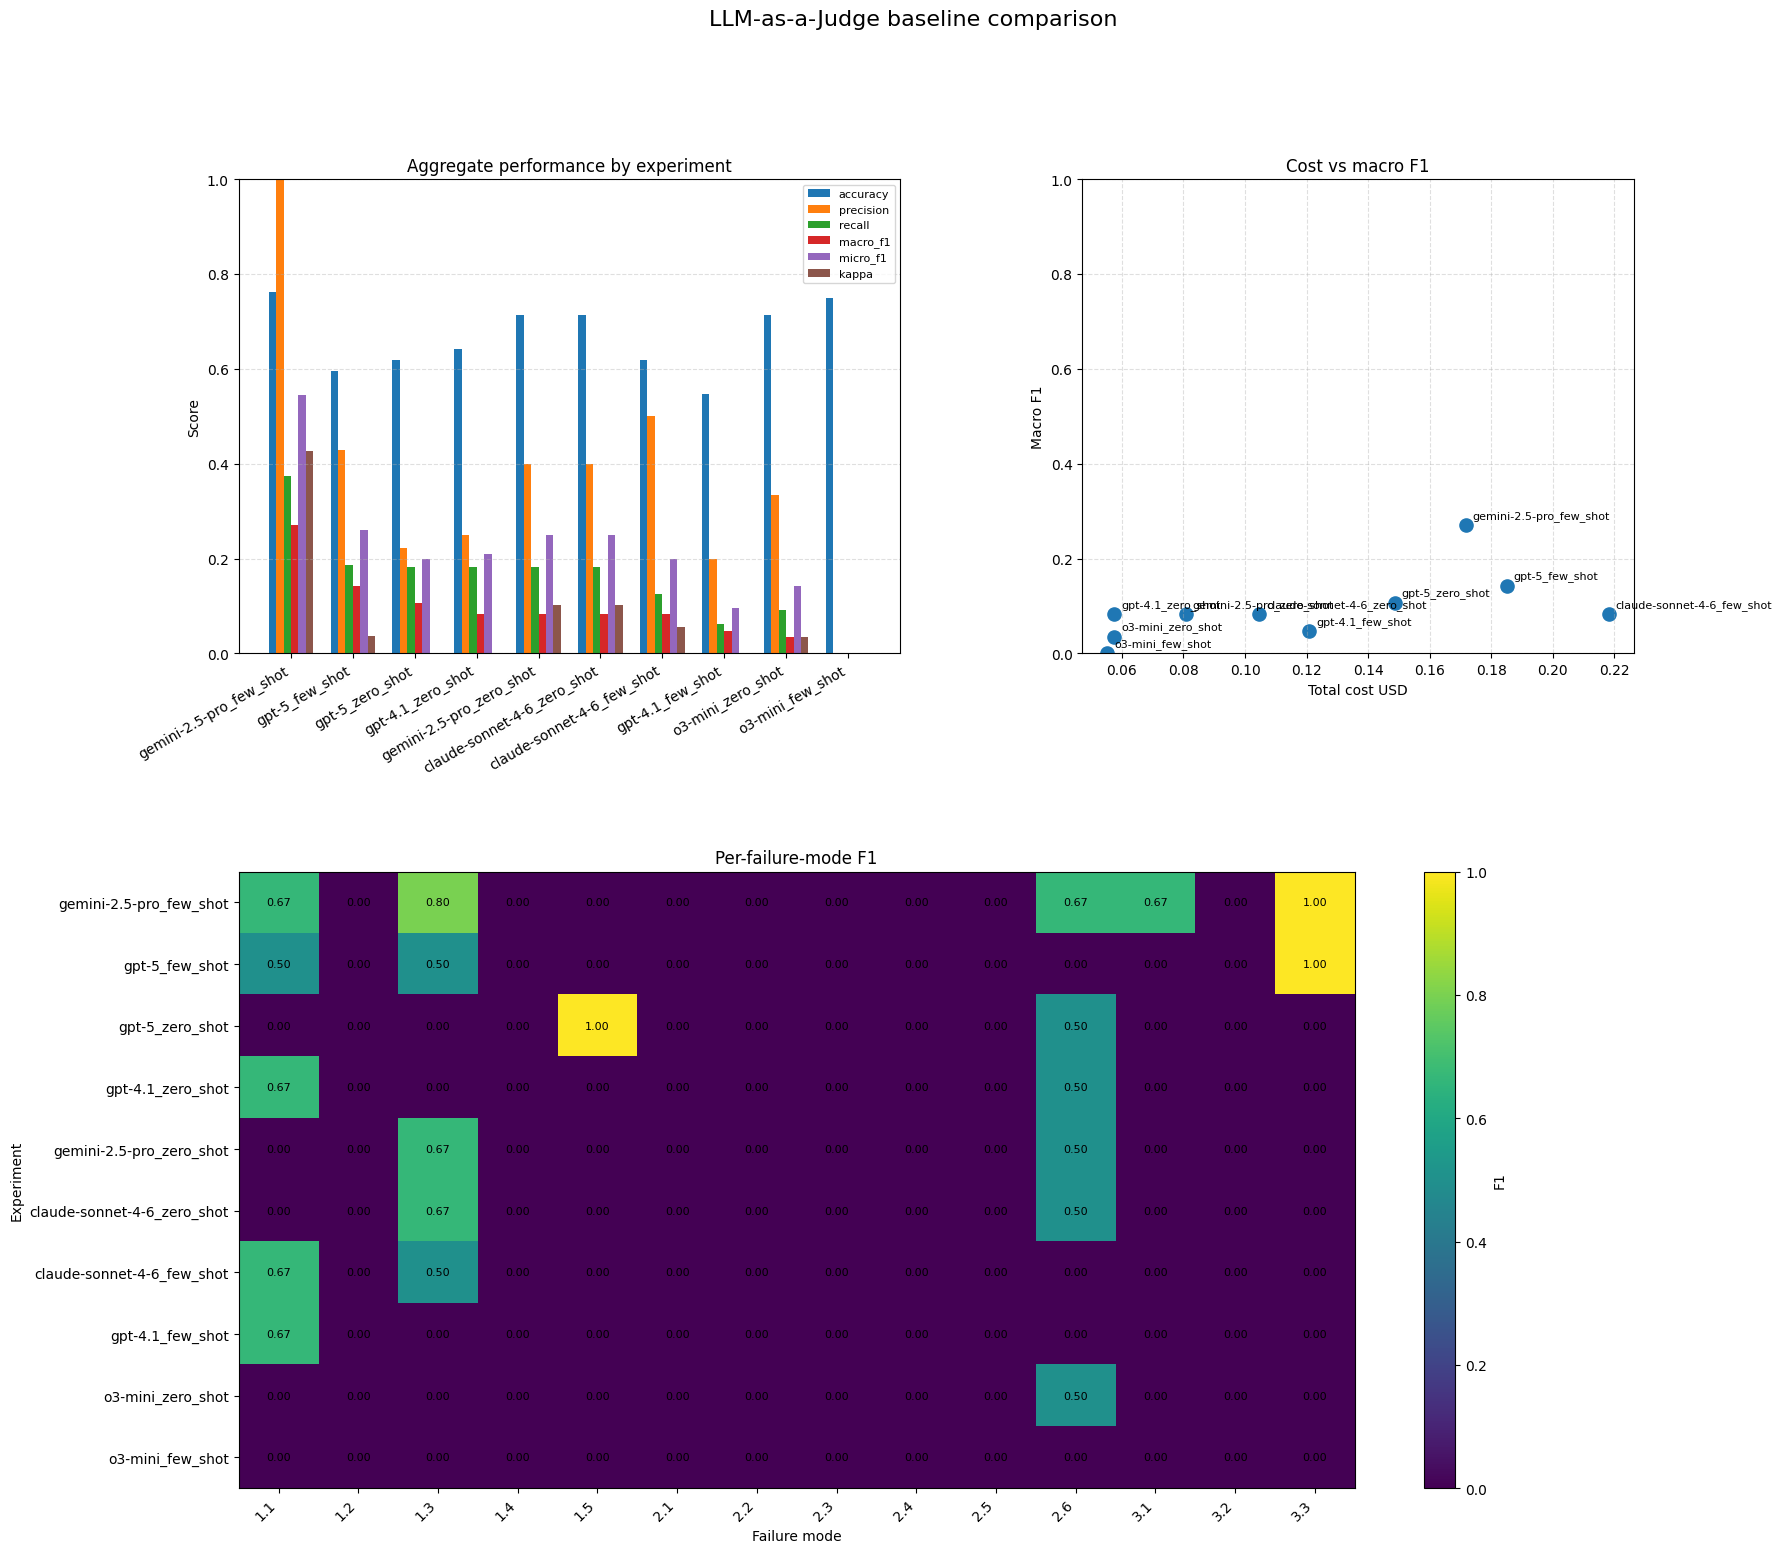


### Human-labelled dataset


c:\Users\bramn\Desktop\Thesis\agent-evaluation-framework\experiments\stage1_llm_judge\experiment_baseline\baseline_utils.py:373: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved: saved_results/baseline_figure_human.png


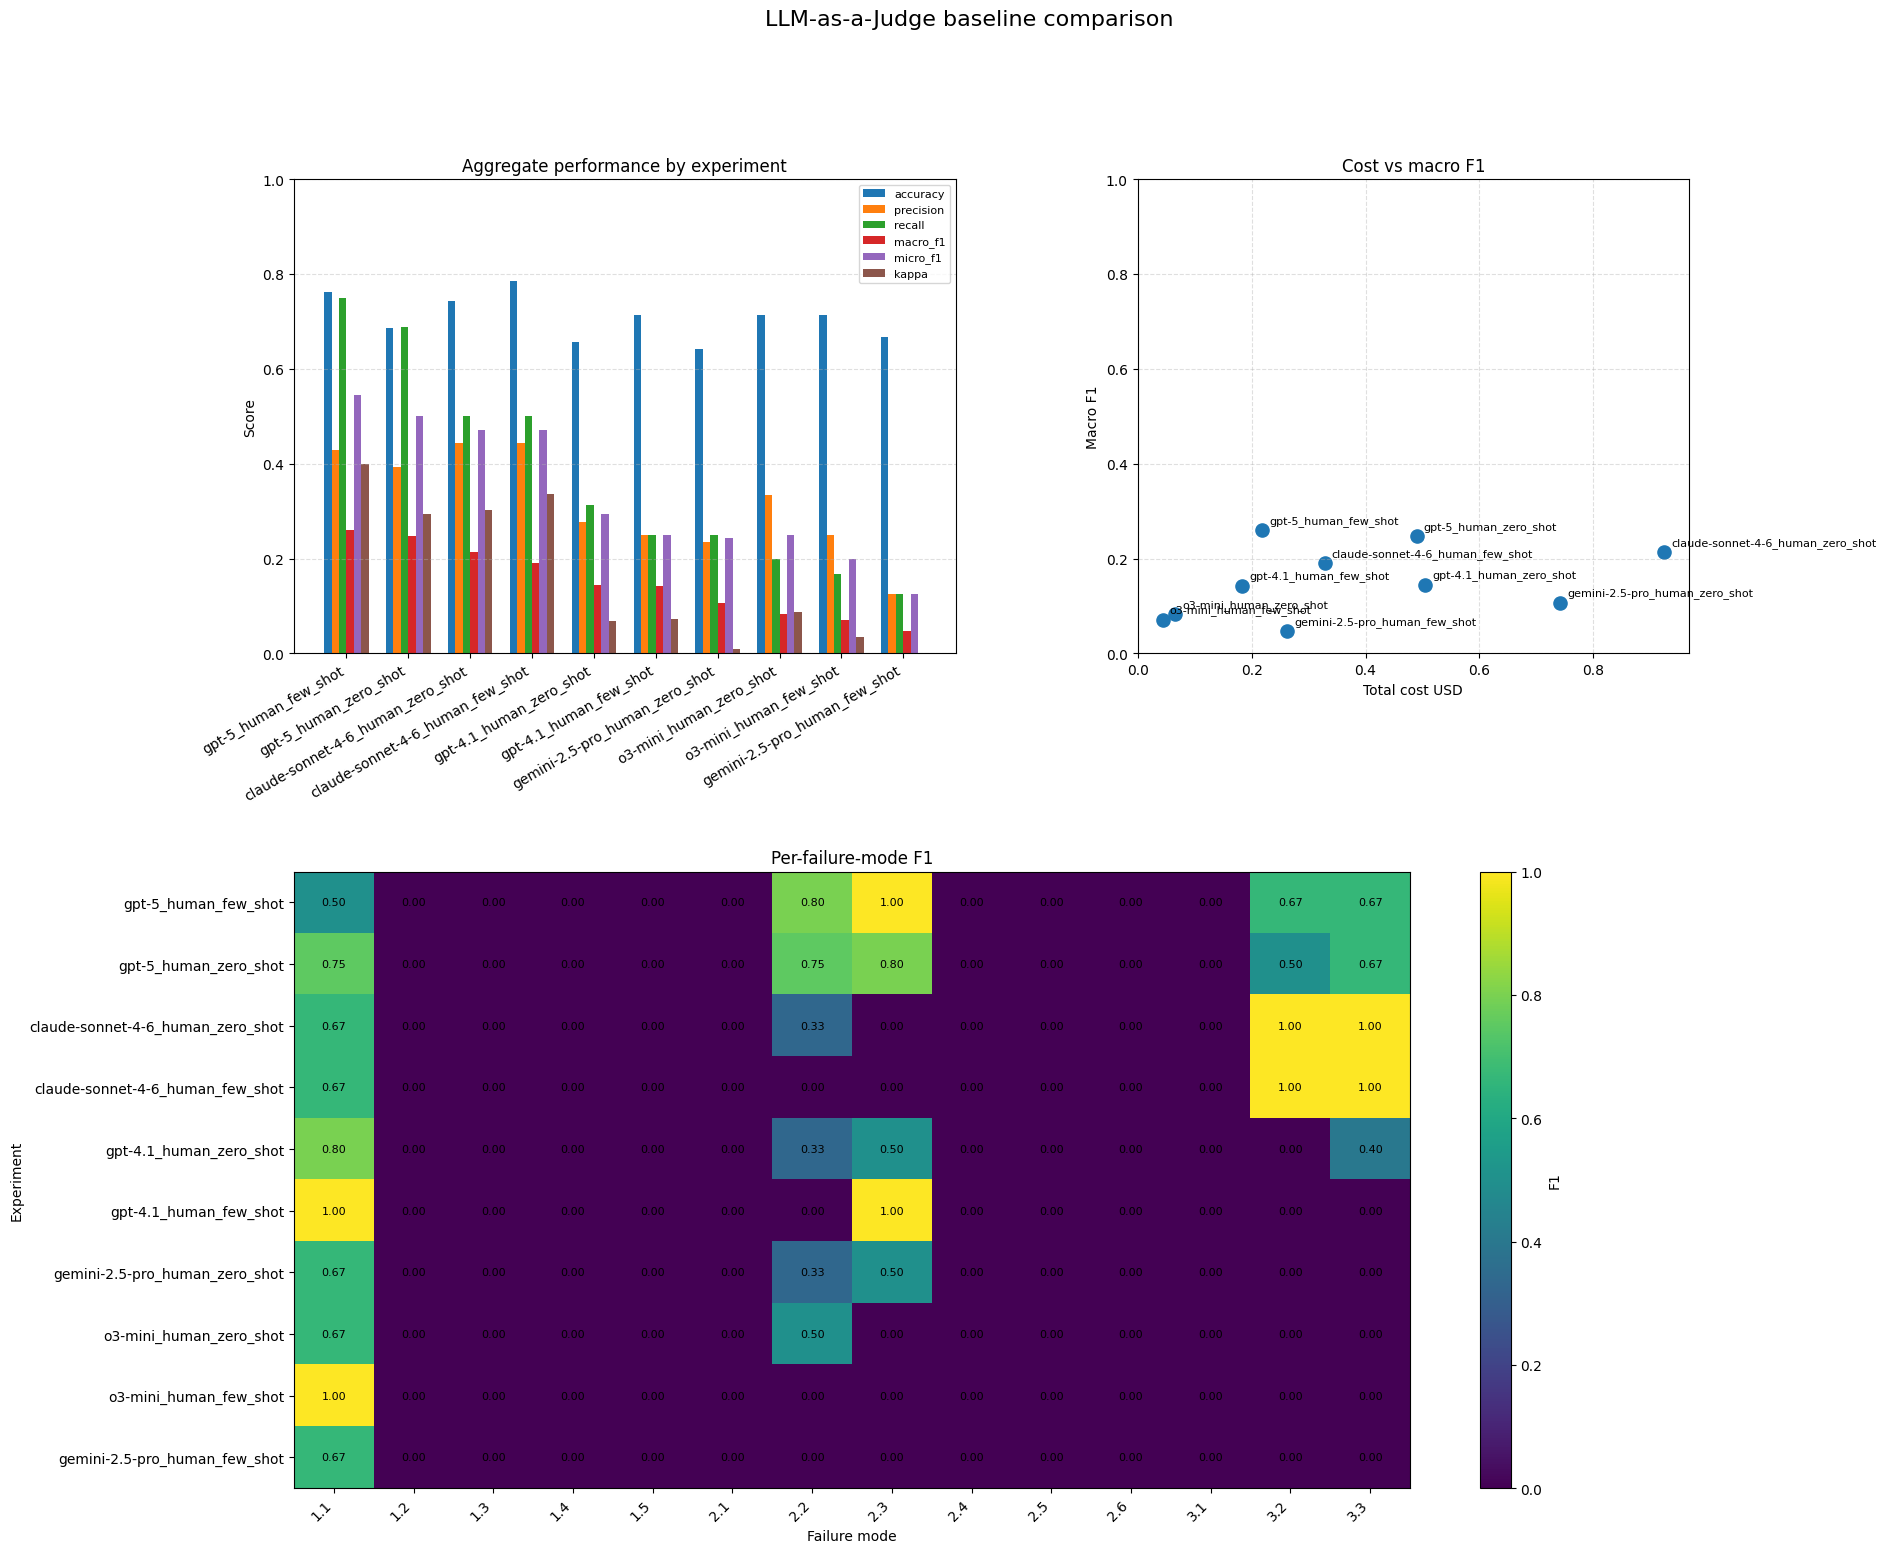

In [22]:
print("### Full dataset")
plot_baseline_figure(decision_table_full,  save_path=f"{RESULTS_DIR}/baseline_figure_full.png")

print("\n### Human-labelled dataset")
plot_baseline_figure(decision_table_human, save_path=f"{RESULTS_DIR}/baseline_figure_human.png")